# Stellar Luminosity — Regresión Lineal y Polinómica desde Cero

## 1. Establecer el ambiente

In [2]:
# Install required libraries (run this once if needed)
%pip install numpy pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)

Python: 3.14.6 (main, Jul 23 2026, 14:44:54) [MSC v.1944 64 bit (AMD64)]
NumPy: 2.5.1
Matplotlib: 3.11.1


Load the dataset as NumPy arrays.

In [4]:
# Datos
mass = [0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4]
luminosity = [0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0]

# Convertir a arreglos de NumPy
mass = np.array(mass)
luminosity = np.array(luminosity)

Confirm the shapes and ranges of the variables.

In [5]:
# Formas (shapes)
print("Forma de mass:", mass.shape)
print("Forma de luminosity:", luminosity.shape)

# Rangos
print("Rango de mass:", mass.min(), "a", mass.max())
print("Rango de luminosity:", luminosity.min(), "a", luminosity.max())

Forma de mass: (10,)
Forma de luminosity: (10,)
Rango de mass: 0.6 a 2.4
Rango de luminosity: 0.15 a 35.0


## 2. Explorar antes de modelar

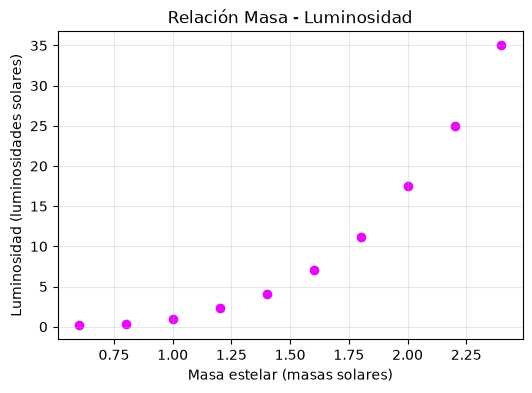

In [6]:
plt.figure(figsize=(6,4))
plt.scatter(mass, luminosity, color="#E808FC")
plt.xlabel("Masa estelar (masas solares)")
plt.ylabel("Luminosidad (luminosidades solares)")
plt.title("Relación Masa - Luminosidad")
plt.grid(True, alpha=0.3)
plt.show()

Describe the observed relationship.

la relación entre la masa estelar y la luminosidad es no lineal, para valores entre 0 y 1.50, son más cercanos, despues de este valor los valores suelen ser cada vez más separados, hasta llegar a 35 luminosidades para un valor entre 2.25 y 2.50.

Explain whether a straight line appears adequate and where systematic errors might occur.

Una linea no es adecuada, ya que no captura bien la curvatura, lo que se puede evidenciar es posiblemnete una polinomica.
Los errores se podrian producir en los extremos y se podrian producir valores no realistas en el contexto.

## 3. Implement the learning algorithm

We now implement the model and cost function using **NumPy arrays** and **vectorized operations**.

### 3.1 Hypothesis $f_{w,b}(x)$

For one house with four features, the model is:

$$
f_{w,b}(x) = w_1x_1 + w_2x_2 + w_3x_3 + w_4x_4 + b
$$

For all houses at once, the vectorized formula is:

$$
\hat{y} = Xw + b
$$

In NumPy, `X @ w` means matrix-vector multiplication.

In [7]:
def predict(X,w,b):
    return X @ w + b

### Cost Function $J(w,b)$ (Vectorized)

We recall
$$
J(w,b) = \frac{1}{2m} \sum_{i=1}^{m} \big( f_{w,b}(x^{(i)}) - y^{(i)} \big)^2.
$$

In vector form, if we define the error vector $e = \hat{y} - y$, then
$$
J(w,b) = \frac{1}{2m} e^T e.
$$


In [8]:
def compute_cost(X,y,w,b):
    m = X.shape[0]
    y_hat = predict(X,w,b)
    error = y_hat -y
    cost = (error @ error) /(2 * m)

    return cost 

## compute gradient

In [9]:
def compute_gradient(X,y,w,b):
    m = X.shape[0]
    y_hat = predict(X,w,b)
    error = y_hat -y

    dj_dw = (X.T @ error) / m
    dj_db = np.sum(error) / m

    return dj_dw, dj_db

## gradient_descent

In [10]:
def gradient_descent(X, y, w_init , b_init, alpha, num_iterations, print_progress = True):
    w = w_init.copy()
    b = b_init
    history_it = []
    history_cost = []

    for i in range(num_iterations):
        dj_dw, dj_db = compute_gradient(X,y,w,b)
        w -= alpha * dj_dw
        b -= alpha * dj_db

        cost = compute_cost(X,y,w,b)
        history_it.append(i)
        history_cost.append(cost)

        if print_progress and (i % max(1, num_iterations // 10) or i == num_iterations -1):
            print(f"Iteración {i:5d}: Costo {cost:10.4f}")

    return w, b, history_it, history_cost

## Train a linear model

In [11]:
X_linear = mass.reshape(-1, 1)
print("X_linear shape:", X_linear.shape)

# inicializamos los parametros
w_init = np.zeros(1)
b_init = 0.0

#Elegimos la tasa de aprendizaje e iteraciones
learning_rate = 0.01
iterations = 10000

# Entrenar
w_lin, b_lin, it_lin, cost_lin = gradient_descent(X_linear, luminosity, w_init, b_init, learning_rate, iterations)

print("w final: ", w_lin)
print("b final: ", b_lin)
print("Costo final: ", cost_lin[-1])


X_linear shape: (10, 1)
Iteración     1: Costo   106.8632
Iteración     2: Costo   101.9913
Iteración     3: Costo    97.4498
Iteración     4: Costo    93.2159
Iteración     5: Costo    89.2687
Iteración     6: Costo    85.5885
Iteración     7: Costo    82.1571
Iteración     8: Costo    78.9573
Iteración     9: Costo    75.9734
Iteración    10: Costo    73.1905
Iteración    11: Costo    70.5949
Iteración    12: Costo    68.1738
Iteración    13: Costo    65.9152
Iteración    14: Costo    63.8080
Iteración    15: Costo    61.8418
Iteración    16: Costo    60.0070
Iteración    17: Costo    58.2947
Iteración    18: Costo    56.6963
Iteración    19: Costo    55.2042
Iteración    20: Costo    53.8109
Iteración    21: Costo    52.5099
Iteración    22: Costo    51.2947
Iteración    23: Costo    50.1596
Iteración    24: Costo    49.0989
Iteración    25: Costo    48.1077
Iteración    26: Costo    47.1811
Iteración    27: Costo    46.3148
Iteración    28: Costo    45.5046
Iteración    29: Costo  

Grafica costo en funcion de la iteracion

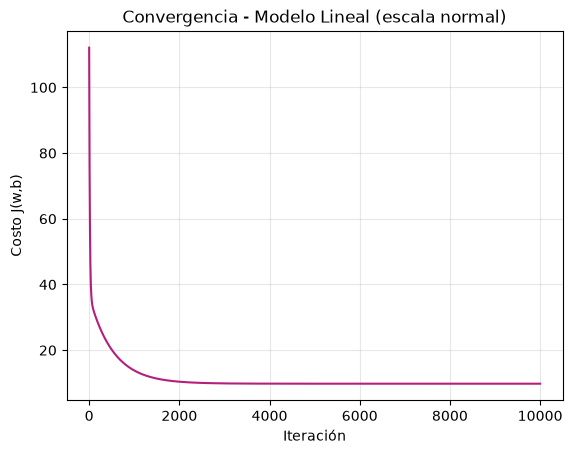

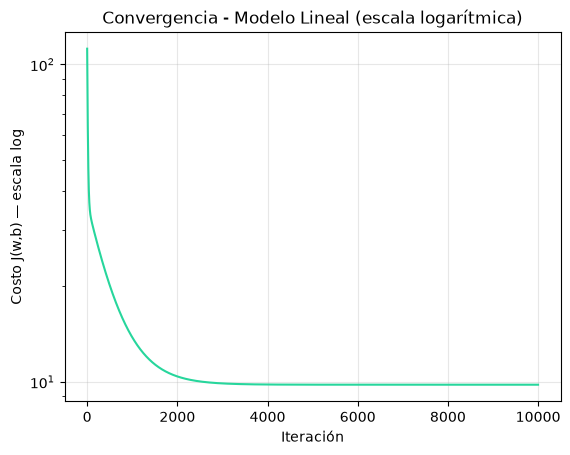

In [14]:
plt.figure()
plt.plot(it_lin, cost_lin, color="#B41F7D")
plt.xlabel("Iteración")
plt.ylabel("Costo J(w,b)")
plt.title("Convergencia - Modelo Lineal (escala normal)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure()
plt.semilogy(it_lin, cost_lin, color="#27D69C")
plt.xlabel("Iteración")
plt.ylabel("Costo J(w,b) — escala log")
plt.title("Convergencia - Modelo Lineal (escala logarítmica)")
plt.grid(True, alpha=0.3)
plt.show()

Estas graficas nos muestran como va bajando la cantidad de errores a medida que pasa las iteraciones, el eje X nos muestra el descenso del gradiente y el eje Y, nos dice que tan mal se esta prediciendo el modelo en esa iteración.

Al principio como pusimos la "w" y "b" en 0, el modelo no sabia nada por lo que el costo era muy alto, luego en las iteraciones entre (0,2100) aproximadamente, se evidencia que ya esta aprendiendo el modelo esto se evidencia porque el costo es cada vez menor en cada iteracion.

Cuando llega a la iteración 2100 aproximadamente vemos que se estabiliza la curva en 10, lo cual nos da como indicio que convergio.

### Modelo lineal ajustado sobre los datos

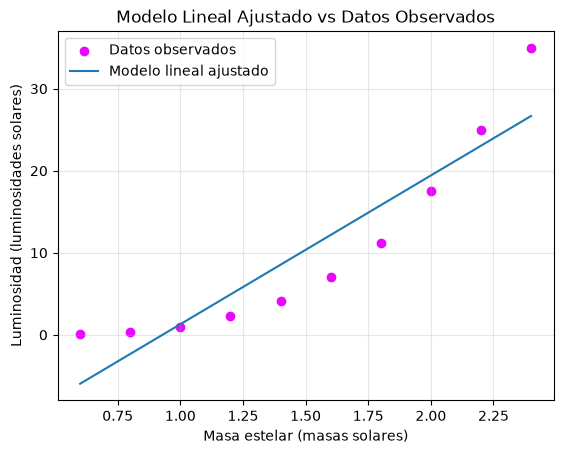

In [16]:
plt.figure()
plt.scatter(mass, luminosity, color="#E808FC", label="Datos observados")

mass_range = np.linspace(mass.min(), mass.max(), 100).reshape(-1, 1)
luminosity_pred = predict(mass_range, w_lin, b_lin)

plt.plot(mass_range, luminosity_pred, color ="#1F77B4",label="Modelo lineal ajustado")

plt.xlabel("Masa estelar (masas solares)")
plt.ylabel("Luminosidad (luminosidades solares)")
plt.title("Modelo Lineal Ajustado vs Datos Observados")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Reporte final y diagnóstico

**Costo final:** ≈ 10
**Diagnóstico de convergencia:**
El descenso de gradiente convergió correctamente: el costo bajó de forma monótona(sin oscilaciones) desde ~100 hasta estabilizarse en ~10 alrededor de la iteración 2100, confirmado tanto en escala normal como logarítmica.